1 veri seti inceleme

sklearn : makine öğrenmesi kütüphanesi

In [90]:
from sklearn.datasets import load_breast_cancer #  göğüs kanser veri setimizi import ediyoruz

In [91]:
import pandas as pd

In [92]:
cancer=load_breast_cancer()


In [93]:
df =pd.DataFrame(data =cancer.data, columns=cancer.feature_names )

In [94]:
df["target"]=cancer.target

2 makine öğrenmesi  modelinin seçilmesi knn sınıflandırma

3 modelin train edilmesi 

In [95]:
from sklearn.neighbors import KNeighborsClassifier

In [96]:
X=cancer.data
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [97]:
y =cancer.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [14]:
knn = KNeighborsClassifier() # model oluşturma 

In [20]:
knn.fit(X,y) # fit fonksiyonu verimizi samples + target  kullanarak knn algoritmansını eğitir

KNeighborsClassifier()

4 sonuçların değerlendirilmesi

In [ ]:
y_pred=knn.predict(X) #burda test ve eğitimi aynı veri üzerinden yaptık bu hatalı ayırmamız lazım

In [98]:
from sklearn.metrics import accuracy_score

In [28]:
accuracy=accuracy_score(y,y_pred=y_pred) # gerçek sonuç olan y ile tahminimiz olan y pred i karşılaştırı

In [29]:
print("Dogruluk: ",accuracy)

Dogruluk:  0.9472759226713533


! şimdi train test olarak ayıralım bu doğru yöntem

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
X_train , X_test, y_train, y_test=train_test_split(X,y,test_size=0.3 ,random_state=42)

In [ ]:
knn1=KNeighborsClassifier(n_neighbors=3)

In [35]:
knn1.fit(X_train,y_train)

KNeighborsClassifier()

In [36]:
y_pred = knn.predict(X_test)

In [37]:
accuracy1=accuracy_score(y_test,y_pred) # gerçek sonuç olan y ile tahminimiz olan y pred i karşılaştırı

In [38]:
print("dogruluk : ",accuracy1)

dogruluk :  0.9707602339181286


Veri setini eğitmeden önce standardize etmek gerekli onu yapalım


Standardizasyon

In [101]:
from sklearn.preprocessing import StandardScaler

In [102]:
knn2=KNeighborsClassifier(n_neighbors=3)

In [103]:
scaler =StandardScaler()

In [104]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test) #0 ve 1 arasına girmiş 

In [105]:
knn2.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [106]:
y_pred=knn2.predict(X_test)
accuracy2=accuracy_score(y_test,y_pred)
print("doğruluk : ",accuracy2)

doğruluk :  0.9590643274853801


In [107]:
from sklearn.metrics import confusion_matrix

In [108]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion_matrix : \n",conf_matrix)

confusion_matrix : 
 [[ 59   4]
 [  3 105]]


5 hiperparametre ayarlaması

k değerini seçerek optimizasyon yapacağız 1 , 2 , 3 ,4 ... n
her k için acc değerini hesaplarız ve en iyi olan k yı seçeriz 

In [89]:
X_train , X_test, y_train, y_test=train_test_split(X,y,test_size=0.3 ,random_state=42)

ValueError: Found input variables with inconsistent numbers of samples: [569, 171]

In [109]:
accuracy_values=[]
k_values=[]
for i in range (1,21):
    knn3=KNeighborsClassifier(n_neighbors=i)
    knn3.fit(X_train,y_train)
    y=pred=knn3.predict(X_test)
    accuracy3=accuracy_score(y_test,y_pred)
    accuracy_values.append(accuracy3)
    k_values.append(i)
   





In [110]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'dogruluk')

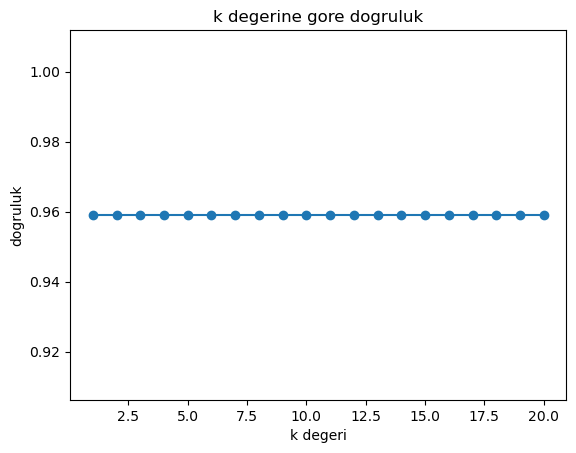

In [112]:
plt.figure()
plt.plot(k_values , accuracy_values ,marker="o", linestyle ="-")
plt.title("k degerine gore dogruluk")
plt.xlabel("k degeri")
plt.ylabel("dogruluk")